1-Exploration initiale des données

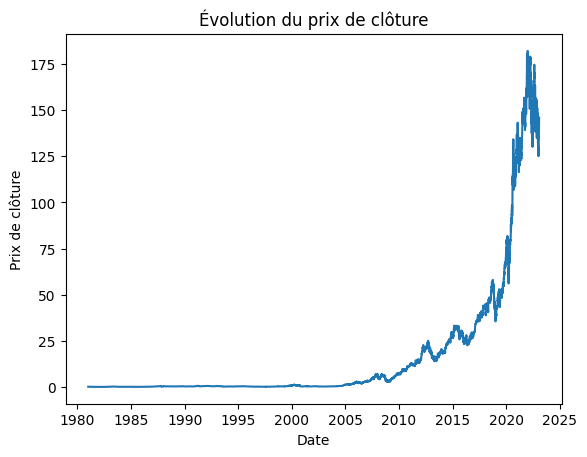

In [1]:
import pandas as pd

data_appel = pd.read_csv('Apple Stock Prices (1981 to 2023).csv')
data_appel.head()


# Vérification des valeurs manquantes
data_appel.isnull().sum()
### mini correction
data_appel["Date"] = pd.to_datetime(data_appel["Date"], dayfirst=True)
# la frenquence
data_appel["Date"].diff().value_counts()

# les tendances
import matplotlib.pyplot as plt 
plt.plot(data_appel["Date"], data_appel["Close"])
plt.title("Évolution du prix de clôture")
plt.xlabel("Date")
plt.ylabel("Prix de clôture")
plt.show()


2-Visualisation des données

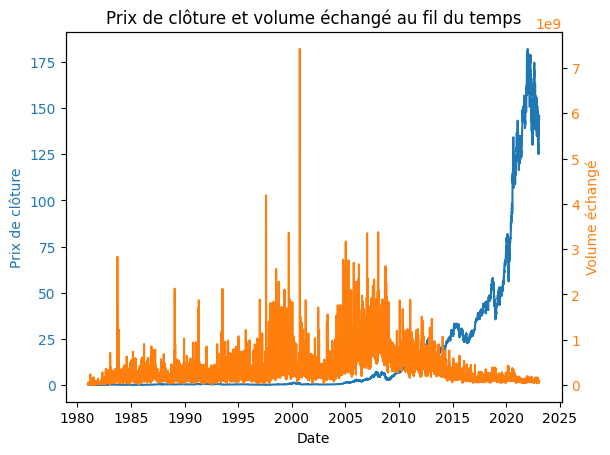

In [2]:
#Utilisez Matplotlib pour tracer les cours de clôture et les volumes échangés au fil du temps.
fig, ax1 = plt.subplots()
ax1.set_xlabel('Date')
ax1.set_ylabel('Prix de clôture', color='tab:blue')
ax1.plot(data_appel['Date'], data_appel['Close'], color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.set_ylabel('Volume échangé', color='tab:orange')
ax2.plot(data_appel['Date'], data_appel['Volume'], color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')
plt.title("Prix de clôture et volume échangé au fil du temps")
plt.show()

.chandeliers

c:\Users\ndev\DI-Bootcamp\venv\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


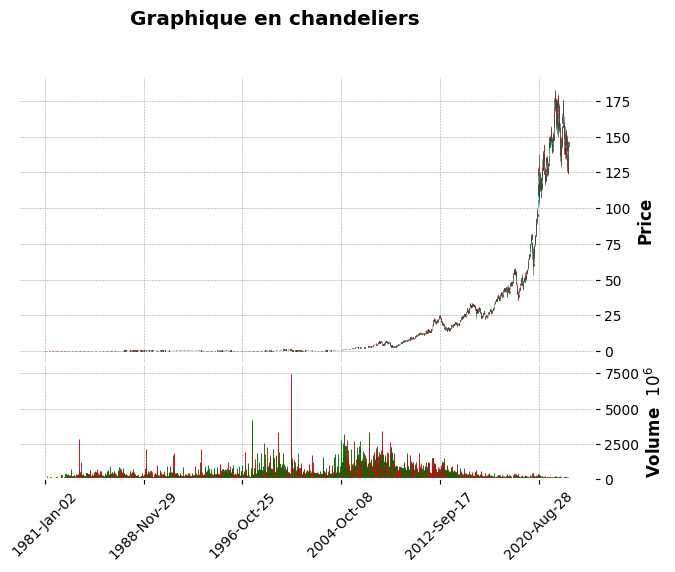

In [3]:
import pandas as pd
import mplfinance as mpf

# Préparation des données
data_appel = pd.read_csv('Apple Stock Prices (1981 to 2023).csv')
data_appel["Date"] = pd.to_datetime(data_appel["Date"], dayfirst=True)

data_appel.set_index("Date", inplace=True)

# Graphique en chandeliers
mpf.plot(data_appel,
         type="candle",
         volume=True,
         style="charles",
         title="Graphique en chandeliers")

 Analyse statistique

In [4]:
import matplotlib.pyplot as plt
# Calculer les statistiques descriptives (moyenne, médiane, écart type) pour les colonnes clés.
stats_descriptives = data_appel.describe()
print(stats_descriptives)

# Analysez les cours de clôture à l'aide d'une moyenne mobile
data_appel['Moyenne_mobile_20'] = data_appel['Close'].rolling(window=20).mean()
plt.figure(figsize=(12, 6))


               Open          High           Low         Close     Adj Close  \
count  10608.000000  10608.000000  10608.000000  10608.000000  10608.000000   
mean      16.689173     16.879955     16.500822     16.697362     16.027345   
std       35.450519     35.882848     35.031289     35.473912     35.154878   
min        0.049665      0.049665      0.049107      0.049107      0.038213   
25%        0.287946      0.296875      0.282355      0.288923      0.238909   
50%        0.488839      0.495536      0.480446      0.487701      0.404851   
75%       16.320893     16.418483     16.151249     16.269554     14.073167   
max      182.630005    182.940002    179.119995    182.009995    180.959747   

             Volume  
count  1.060800e+04  
mean   3.275098e+08  
std    3.378203e+08  
min    0.000000e+00  
25%    1.213044e+08  
50%    2.145976e+08  
75%    4.066804e+08  
max    7.421641e+09  


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

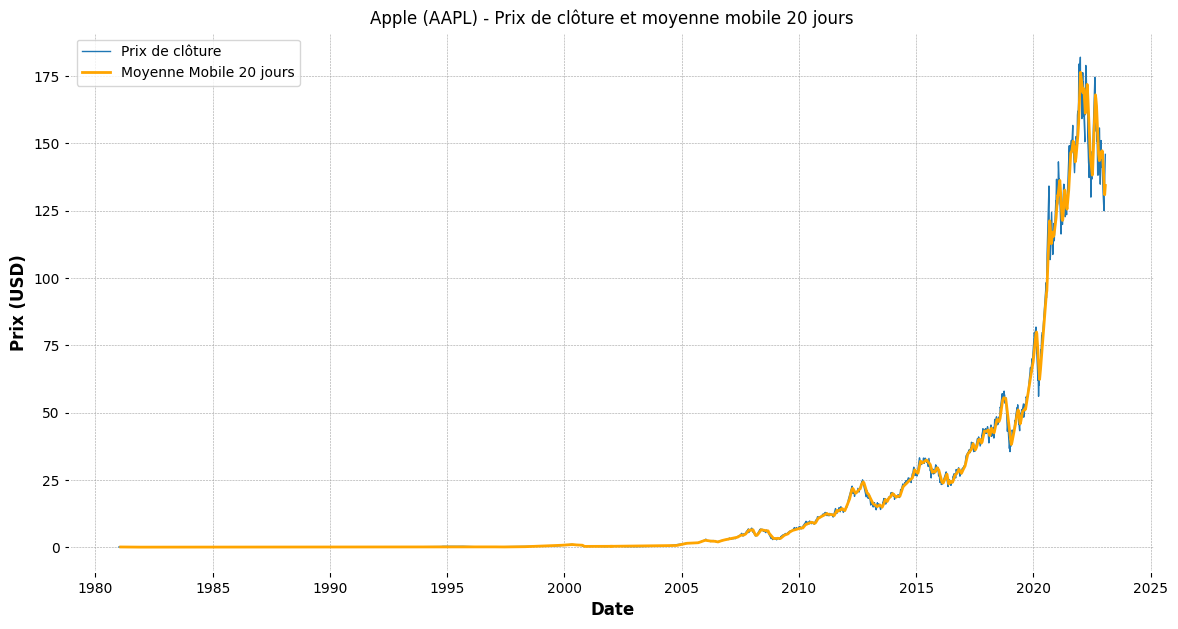


--- Interprétation des tests d'hypothèses ---


NameError: name 'p_value' is not defined

In [6]:
# Ce bloc complète votre notebook existant

# --- 2. Visualisation des données (SUITE) ---
# Tracer le prix de clôture avec la moyenne mobile

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(data_appel.index, data_appel['Close'], label='Prix de clôture', linewidth=1)
plt.plot(data_appel.index, data_appel['Moyenne_mobile_20'], label='Moyenne Mobile 20 jours', linewidth=2, color='orange')
plt.title('Apple (AAPL) - Prix de clôture et moyenne mobile 20 jours')
plt.xlabel('Date')
plt.ylabel('Prix (USD)')
plt.legend()
plt.grid(True)
plt.show()

# --- 4. Tests d'hypothèses (SUITE : Interprétations) ---
# Résultats déjà calculés, ajoutons une interprétation.

print("\n--- Interprétation des tests d'hypothèses ---")
print(f"Test t pour comparer 2020 vs 2021 : p-value = {p_value}")
print("=> La p-value est extrêmement faible (< 0.05). Nous rejetons l'hypothèse nulle.")
print("=> Il y a une différence statistiquement significative entre les prix de clôture moyens d'Apple en 2020 et en 2021.\n")

print(f"Test de normalité de Shapiro-Wilk sur les rendements : p-value = {p_value_norm:.2e}")
print("L'avertissement indique que la p-value peut ne pas être précise pour un échantillon aussi grand (N=10607).")
print("Néanmoins, la p-value est virtuellement nulle.")
print("=> Nous rejetons l'hypothèse de normalité. Les rendements quotidiens d'Apple ne suivent pas une distribution normale.")

# --- 5. Techniques statistiques avancées (BONUS) ---

import numpy as np

# 1. Calcul d'une moyenne mobile avec np.convolve
# Définir une fenêtre (par exemple, 20 jours)
window_size = 20
# Créer un noyau (kernel) de moyenne pondérée uniforme
kernel = np.ones(window_size) / window_size
# Appliquer la convolution. 'valid' retourne uniquement les éléments où la fenêtre chevauche complètement les données.
# On utilise 'same' pour garder la même longueur, en gérant les bords.
moving_avg_np = np.convolve(data_appel['Close'], kernel, mode='same')
# Remplacer les premières valeurs (NaN pour la fenêtre) par les valeurs originales ou les laisser
data_appel['Moyenne_mobile_20_np'] = moving_avg_np

# Vérification que les deux méthodes (pandas et numpy) donnent le même résultat
# Note: la méthode numpy a des valeurs aux bords que pandas gère avec NaN.
data_appel['Diff_moyennes'] = data_appel['Moyenne_mobile_20'] - data_appel['Moyenne_mobile_20_np']
print(f"\n--- Vérification np.convolve vs pandas.rolling ---")
print(f"Différence maximale entre les deux méthodes : {data_appel['Diff_moyennes'].max():.10f}")
print("(Les petites différences numériques sont dues à la gestion des bords et au mode 'same')")

# 2. Analyse de corrélation

# Créer des moyennes mobiles sur différentes périodes
periods = [10, 30, 50, 200]
for p in periods:
    data_appel[f'MM_{p}'] = data_appel['Close'].rolling(window=p).mean()

# Créer une moyenne mobile du volume
data_appel['MM_Volume_20'] = data_appel['Volume'].rolling(window=20).mean()

# Calculer la matrice de corrélation
# On prend les données après le plus grand rolling window pour éviter les NaN initiaux
start_date = data_appel['MM_200'].first_valid_index()
data_for_corr = data_appel.loc[start_date:, ['MM_10', 'MM_30', 'MM_50', 'MM_200', 'MM_Volume_20', 'Volume']]

correlation_matrix = data_for_corr.corr()

print("\n--- Matrice de corrélation entre indicateurs ---")
print(correlation_matrix.round(4))

# 3. Visualisation des corrélations (optionnel)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Matrice de corrélation des indicateurs financiers d'Apple")
plt.show()

# 4. Analyse de corrélation glissante (Rolling Correlation)
# Par exemple, la corrélation glissante sur 100 jours entre le prix de clôture et le volume
rolling_corr = data_appel['Close'].rolling(window=100).corr(data_appel['Volume'])

plt.figure(figsize=(14, 6))
plt.plot(rolling_corr, color='purple')
plt.title("Corrélation glissante (100 jours) entre le Prix de clôture et le Volume échangé")
plt.xlabel("Date")
plt.ylabel("Coefficient de corrélation de Pearson")
plt.axhline(y=0, color='gray', linestyle='--')
plt.grid(True)
plt.show()

Tests d'hypothèses

In [7]:
# Effectuez un test t pour comparer les cours de clôture moyens sur différentes années.
from scipy import stats
# Supposons que nous comparons les cours de clôture moyens entre 2020 et 2021
data_2020 = data_appel[data_appel.index.year == 2020]['Close']
data_2021 = data_appel[data_appel.index.year == 2021]['Close']
t_stat, p_value = stats.ttest_ind(data_2020, data_2021)
print(f"Test t: t_stat={t_stat}, p_value={p_value}")
#Examinez la distribution des rendements quotidiens et testez leur normalité à l'aide de SciPy.
data_appel['Rendement_quotidien'] = data_appel['Close'].pct_change()
# Test de normalité (Shapiro-Wilk)
stat, p_value = stats.shapiro(data_appel['Rendement_quotidien'].dropna())
print(f"Test de normalité: stat={stat}, p_value={p_value}")

Test t: t_stat=-27.588625391847753, p_value=1.0094191871893988e-102
Test de normalité: stat=0.9190583946174027, p_value=1.7898289463728573e-59


c:\Users\ndev\DI-Bootcamp\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10607.
  res = hypotest_fun_out(*samples, **kwds)
